# Pathologist Disagreement Analysis

This notebook generates tile-level label dataframes for Anna and Grayson for all **24 overlapping slides**, merges them on tile coordinates, and analyzes agreement/disagreement.

## Overlapping Slides (24)
- **14 Exp1 AF slides**: AF102F, AF104, AF107, AF109, AF110F, AF113M, AF130F, AF135M, AF136M, AF238F, AF239F, AF252, AF254F, AF257M
- **9 Exp2 AG/AH slides**: AG985F, AG986F, AG987F, AG991M, AH063F, AH073M, AH074M, AH139F, AH141F
- **1 additional**: AH072M

## Workflow
1. Extract Grayson tiles for the 9 Exp2 slides (15 AF+AH072M already done)
2. Build Dataset objects filtered to 24 slides
3. Generate tile dataframes via `get_tile_dataframe()`
4. Merge dataframes on slide + x/y coordinates
5. Analyze agreement/disagreement
6. Visualize on UMAP

In [1]:
import slideflow as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Slideflow version: {sf.__version__}')

Slideflow version: 3.0.2


In [27]:
# --- Paths & config ---

#ask about the setup here the features directory is where foundation model features are stored right?? 
# Ask about the structure of the docs too! 
PROJECT_DIR = '/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo'
FEATURES_DIR = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/virchow'

TILE_PX = 299
TILE_UM = 302

# All 24 overlapping slides (both Anna and Grayson annotated)
OVERLAP_SLIDES = [
    # Exp1 AF slides (14)
    'AF102F', 'AF104', 'AF107', 'AF109', 'AF110F', 'AF113M',
    'AF130F', 'AF135M', 'AF136M', 'AF238F', 'AF239F', 'AF252', 'AF254F', 'AF257M',
    # Exp2 AG/AH slides (9)
    'AG985F', 'AG986F', 'AG987F', 'AG991M',
    'AH063F', 'AH073M', 'AH074M', 'AH139F', 'AH141F',
    # Additional (1)
    'AH072M'
]


## Step 2 — Build Dataset Objects

We create two separate Dataset objects filtered to all **24 overlapping slides**:
- **Anna**: `Exp2_Dataset` source — her ROIs and tiles
- **Grayson**: `Grayson_Dataset` source — his ROIs and tiles

Note: Grayson already has tiles for the 14 AF slides + AH072M. The 9 Exp2 AG/AH slides need extraction (see Step 1b below).

In [28]:
project = sf.Project(PROJECT_DIR)
print(project)

Project(root='/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo')


In [29]:
# Anna's dataset — filtered to 24 overlap slides
anna_ds = project.dataset(sources='Exp2_Dataset', tile_px=TILE_PX, tile_um=TILE_UM)
anna_ds = anna_ds.filter({'slide': OVERLAP_SLIDES})
print(f'Anna dataset slides: {len(anna_ds.slides())}')

# Grayson's dataset — filtered to 24 overlap slides
grayson_ds = project.dataset(sources='Grayson_Dataset', tile_px=TILE_PX, tile_um=TILE_UM)
grayson_ds = grayson_ds.filter({'slide': OVERLAP_SLIDES})
print(f'Grayson dataset slides: {len(grayson_ds.slides())}')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Anna dataset slides: 24


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Grayson dataset slides: 24


## Step 3 — Generate Tile Dataframes

`get_tile_dataframe()` returns one row per tile with:
- `slide` — slide name
- `x`, `y` — tile center coordinates (base dimension)
- `grid` — slide grid index
- `roi_name` — the ROI label the tile falls within (tiles outside all ROIs are excluded)

In [18]:
print('Generating Anna tile dataframe...')
anna_tile_df = anna_ds.get_tile_dataframe()
anna_tile_df = anna_tile_df.loc[anna_tile_df.label.notnull()]
print(f'Anna tiles (in ROI): {len(anna_tile_df):,}')
print(anna_tile_df.head())

Generating Anna tile dataframe...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Anna tiles (in ROI): 1,941
                   loc_x  loc_y  grid_x  grid_y roi_name roi_desc   label  \
AF136M-14900-2980  14900   2980      12       2    ROI_4    ROI_4  Benign   
AF136M-16092-2980  16092   2980      13       2    ROI_4    ROI_4  Benign   
AF136M-17284-2980  17284   2980      14       2    ROI_4    ROI_4  Benign   
AF136M-18476-2980  18476   2980      15       2    ROI_4    ROI_4  Benign   
AF136M-19668-2980  19668   2980      16       2    ROI_4    ROI_4  Benign   

                    slide  
AF136M-14900-2980  AF136M  
AF136M-16092-2980  AF136M  
AF136M-17284-2980  AF136M  
AF136M-18476-2980  AF136M  
AF136M-19668-2980  AF136M  


In [26]:
anna_tile_df

,tile_id,loc_x,loc_y,grid_x,grid_y,roi_name,roi_desc,label_anna,slide
0,AF136M-14900-2980,14900,2980,12,2,ROI_4,ROI_4,Benign,AF136M
1,AF136M-16092-2980,16092,2980,13,2,ROI_4,ROI_4,Benign,AF136M
2,AF136M-17284-2980,17284,2980,14,2,ROI_4,ROI_4,Benign,AF136M
3,AF136M-18476-2980,18476,2980,15,2,ROI_4,ROI_4,Benign,AF136M
4,AF136M-19668-2980,19668,2980,16,2,ROI_4,ROI_4,Benign,AF136M
...,...,...,...,...,...,...,...,...,...
1936,AH063F-34953-54435,34953,54435,30,47,ROI_10,ROI_10,Dysplasia,AH063F
1937,AH063F-36099-54435,36099,54435,31,47,ROI_10,ROI_10,Dysplasia,AH063F
1938,AH063F-37245-54435,37245,54435,32,47,ROI_10,ROI_10,Dysplasia,AH063F
1939,AH063F-33807-55581,33807,55581,29,48,ROI_10,ROI_10,Dysplasia,AH063F


In [20]:
print('Generating Grayson tile dataframe...')
grayson_tile_df = grayson_ds.get_tile_dataframe()
grayson_tile_df = grayson_tile_df.loc[grayson_tile_df.label.notnull()]
print(f'Grayson tiles (in ROI): {len(grayson_tile_df):,}')
print(grayson_tile_df.head())

Generating Grayson tile dataframe...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Grayson tiles (in ROI): 2,046
                   loc_x  loc_y  grid_x  grid_y roi_name roi_desc  \
AF136M-14900-2980  14900   2980      12       2    ROI_3    ROI_3   
AF136M-16092-2980  16092   2980      13       2    ROI_3    ROI_3   
AF136M-17284-2980  17284   2980      14       2    ROI_0    ROI_0   
AF136M-18476-2980  18476   2980      15       2    ROI_4    ROI_4   
AF136M-19668-2980  19668   2980      16       2    ROI_4    ROI_4   

                            label   slide  
AF136M-14900-2980          Benign  AF136M  
AF136M-16092-2980          Benign  AF136M  
AF136M-17284-2980  Hyperkeratosis  AF136M  
AF136M-18476-2980          Benign  AF136M  
AF136M-19668-2980          Benign  AF136M  


In [21]:
grayson_tile_df

,loc_x,loc_y,grid_x,grid_y,roi_name,roi_desc,label,slide
AF136M-14900-2980,14900,2980,12,2,ROI_3,ROI_3,Benign,AF136M
AF136M-16092-2980,16092,2980,13,2,ROI_3,ROI_3,Benign,AF136M
AF136M-17284-2980,17284,2980,14,2,ROI_0,ROI_0,Hyperkeratosis,AF136M
AF136M-18476-2980,18476,2980,15,2,ROI_4,ROI_4,Benign,AF136M
AF136M-19668-2980,19668,2980,16,2,ROI_4,ROI_4,Benign,AF136M
...,...,...,...,...,...,...,...,...
AH063F-34953-54435,34953,54435,30,47,ROI_15,ROI_15,Benign,AH063F
AH063F-36099-54435,36099,54435,31,47,ROI_15,ROI_15,Benign,AH063F
AH063F-37245-54435,37245,54435,32,47,ROI_15,ROI_15,Benign,AH063F
AH063F-33807-55581,33807,55581,29,48,ROI_15,ROI_15,Benign,AH063F


In [22]:
# Inspect ROI label distributions
print('Anna ROI labels:')
print(anna_tile_df['label'].value_counts())
print()
print('Grayson ROI labels:')
print(grayson_tile_df['label'].value_counts())

Anna ROI labels:
label
Benign                956
Dysplasia             766
Invasive carcinoma    219
Name: count, dtype: int64

Grayson ROI labels:
label
Benign            1631
Carcinoma          158
Mild               134
Severe              62
Moderate            55
Hyperkeratosis       4
Unknown              2
Name: count, dtype: int64


## Step 4 — Merge Tile Dataframes

Merge Anna and Grayson on `slide + x + y` (inner join = tiles both annotated).
This gives us `roi_name_anna` and `roi_name_grayson` for the same tile.

In [23]:
# Rename label columns before merging
anna_tile_df = anna_tile_df.rename(columns={'label': 'label_anna'})
grayson_tile_df = grayson_tile_df.rename(columns={'label': 'label_grayson'})

# Reset index so tile_id (e.g. AF136M-14900-2980) becomes a regular column
anna_tile_df = anna_tile_df.reset_index().rename(columns={'index': 'tile_id'})
grayson_tile_df = grayson_tile_df.reset_index().rename(columns={'index': 'tile_id'})

# Inner join on slide + tile coordinates; keep tile_id from Anna (identical for shared tiles)
merged_df = pd.merge(
    anna_tile_df[['tile_id', 'slide', 'loc_x', 'loc_y', 'label_anna']],
    grayson_tile_df[['slide', 'loc_x', 'loc_y', 'label_grayson']],
    on=['slide', 'loc_x', 'loc_y'],
    how='inner'
)

print(f'Merged tiles (both annotated same tile): {len(merged_df):,}')
print(f'Anna-only tiles: {len(anna_tile_df) - len(merged_df):,}')
print(f'Grayson-only tiles: {len(grayson_tile_df) - len(merged_df):,}')
merged_df.head()

Merged tiles (both annotated same tile): 1,901
Anna-only tiles: 40
Grayson-only tiles: 145


,tile_id,slide,loc_x,loc_y,label_anna,label_grayson
0,AF136M-14900-2980,AF136M,14900,2980,Benign,Benign
1,AF136M-16092-2980,AF136M,16092,2980,Benign,Benign
2,AF136M-17284-2980,AF136M,17284,2980,Benign,Hyperkeratosis
3,AF136M-18476-2980,AF136M,18476,2980,Benign,Benign
4,AF136M-19668-2980,AF136M,19668,2980,Benign,Benign


In [24]:
# Normalize label synonyms before computing agreement
# Grayson uses "Carcinoma", Anna uses "Invasive carcinoma" — same thing
LABEL_MAP_GRAYSON = {
    'Carcinoma': 'Invasive carcinoma',
}
merged_df['label_grayson_norm'] = merged_df['label_grayson'].replace(LABEL_MAP_GRAYSON)

# Flag agreement using normalized labels
merged_df['agree'] = merged_df['label_anna'] == merged_df['label_grayson_norm']

n_agree = merged_df['agree'].sum()
n_total = len(merged_df)
print(f'Agreement: {n_agree:,} / {n_total:,} tiles ({100*n_agree/n_total:.1f}%)')
print(f'Disagreement: {n_total - n_agree:,} tiles ({100*(n_total - n_agree)/n_total:.1f}%)')
print(f'\n(Note: "Carcinoma" normalized to "Invasive carcinoma" for comparison)')

Agreement: 1,059 / 1,901 tiles (55.7%)
Disagreement: 842 tiles (44.3%)

(Note: "Carcinoma" normalized to "Invasive carcinoma" for comparison)


In [25]:
merged_df

,tile_id,slide,loc_x,loc_y,label_anna,label_grayson,label_grayson_norm,agree
0,AF136M-14900-2980,AF136M,14900,2980,Benign,Benign,Benign,True
1,AF136M-16092-2980,AF136M,16092,2980,Benign,Benign,Benign,True
2,AF136M-17284-2980,AF136M,17284,2980,Benign,Hyperkeratosis,Hyperkeratosis,False
3,AF136M-18476-2980,AF136M,18476,2980,Benign,Benign,Benign,True
4,AF136M-19668-2980,AF136M,19668,2980,Benign,Benign,Benign,True
...,...,...,...,...,...,...,...,...
1896,AH063F-34953-54435,AH063F,34953,54435,Dysplasia,Benign,Benign,False
1897,AH063F-36099-54435,AH063F,36099,54435,Dysplasia,Benign,Benign,False
1898,AH063F-37245-54435,AH063F,37245,54435,Dysplasia,Benign,Benign,False
1899,AH063F-33807-55581,AH063F,33807,55581,Dysplasia,Benign,Benign,False


In [ ]:
merged_df.label_anna

SyntaxError: invalid syntax (93152597.py, line 1)

In [13]:
# Disagreement breakdown using normalized labels
disagree_df = merged_df[~merged_df['agree']]
breakdown = disagree_df.groupby(['label_anna', 'label_grayson_norm']).size().reset_index(name='n_tiles')
breakdown = breakdown.sort_values('n_tiles', ascending=False)
print('Disagreement pairs (Anna label → Grayson label):')
print(breakdown.to_string(index=False))

Disagreement pairs (Anna label → Grayson label):
        label_anna label_grayson_norm  n_tiles
         Dysplasia             Benign      568
         Dysplasia               Mild       99
         Dysplasia             Severe       44
         Dysplasia           Moderate       40
Invasive carcinoma             Benign       28
            Benign               Mild       25
Invasive carcinoma             Severe       17
Invasive carcinoma           Moderate       10
            Benign     Hyperkeratosis        3
         Dysplasia Invasive carcinoma        3
Invasive carcinoma               Mild        2
Invasive carcinoma            Unknown        2
         Dysplasia     Hyperkeratosis        1


## Step 5 — Visualizations

### 5a — Confusion matrix heatmap (Anna vs Grayson labels)

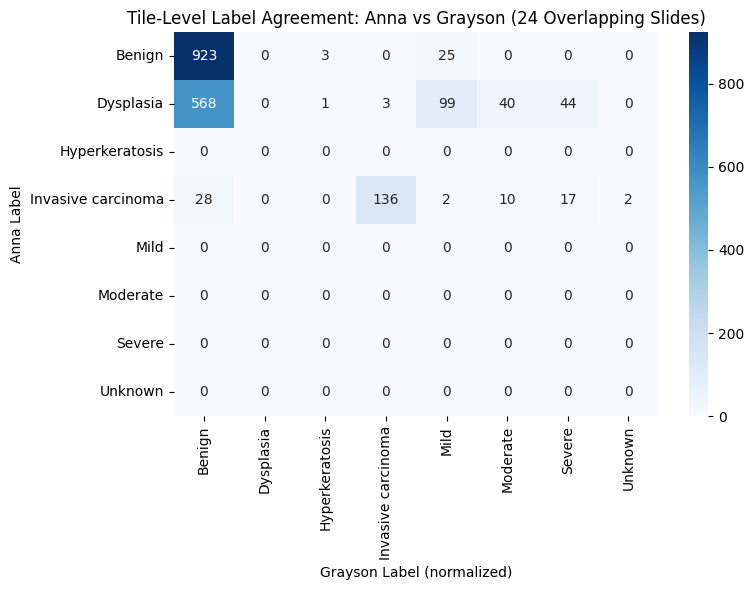

Cohen's Kappa: 0.253


In [14]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score

labels_order = sorted(set(merged_df['label_anna'].unique()) | set(merged_df['label_grayson_norm'].unique()))

cm = confusion_matrix(merged_df['label_anna'], merged_df['label_grayson_norm'], labels=labels_order)
cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Grayson Label (normalized)')
ax.set_ylabel('Anna Label')
ax.set_title('Tile-Level Label Agreement: Anna vs Grayson (24 Overlapping Slides)')
plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/disagreement_confusion_matrix.png', dpi=150)
plt.show()

kappa = cohen_kappa_score(merged_df['label_anna'], merged_df['label_grayson_norm'])
print(f"Cohen's Kappa: {kappa:.3f}")

In [18]:
import numpy as np
import pandas as pd
import torch
from shapely.geometry import Point, Polygon
from pathlib import Path
import umap
import matplotlib.pyplot as plt
import slideflow as sf

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 6 — UMAP of Disagreement

Load Virchow features for all 24 slides, filter to only the merged tiles,
then run UMAP and color by agreement/disagreement.

In [15]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

FEATURE_DIR = Path('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/virchow')

# Load features + coordinates for all 24 slides into a DataFrame
feat_rows = []
feat_vectors = []

for slide in OVERLAP_SLIDES:
    pt_path = FEATURE_DIR / f'{slide}.pt'
    idx_path = FEATURE_DIR / f'{slide}.index.npz'
    if not pt_path.exists():
        print(f'WARNING: {slide}.pt not found, skipping')
        continue
    features = torch.load(pt_path, map_location='cpu').numpy()
    idx = np.load(idx_path)
    coords = idx['arr_0']  # shape: (n_tiles, 2) — (x, y) per tile
    for i, (x, y) in enumerate(coords):
        feat_rows.append({'slide': slide, 'loc_x': int(x), 'loc_y': int(y), 'feat_idx': len(feat_vectors)})
        feat_vectors.append(features[i])
    print(f'{slide}: {len(features)} tiles loaded')

feat_df = pd.DataFrame(feat_rows)
feat_matrix = np.array(feat_vectors)
print(f'\nTotal tiles loaded: {len(feat_df):,}')
print(f'Feature matrix shape: {feat_matrix.shape}')

/tmp/ipykernel_95319/2997100284.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path, map_location='cpu').numpy()


AF102F: 53 tiles loaded
AF104: 53 tiles loaded
AF107: 36 tiles loaded
AF109: 64 tiles loaded
AF110F: 42 tiles loaded
AF113M: 58 tiles loaded
AF130F: 46 tiles loaded
AF135M: 58 tiles loaded
AF136M: 57 tiles loaded
AF238F: 61 tiles loaded
AF239F: 56 tiles loaded
AF252: 37 tiles loaded
AF254F: 56 tiles loaded
AF257M: 47 tiles loaded
AG985F: 113 tiles loaded
AG986F: 87 tiles loaded
AG987F: 91 tiles loaded
AG991M: 61 tiles loaded
AH063F: 112 tiles loaded
AH073M: 86 tiles loaded
AH074M: 136 tiles loaded
AH139F: 111 tiles loaded
AH141F: 98 tiles loaded
AH072M: 108 tiles loaded

Total tiles loaded: 1,727
Feature matrix shape: (1727, 2560)


In [16]:
feat_df
#This shows the tiles that we extracted from just anna and shows their x,y location + we stored the actual features. We are then gonna merge this with our tile dataframe to associate our tiles that have labels from both anna and grayson with actual features! We only need to extract features for either anna or grayson since they are labelling the same slides...so if they share a tile the features for that tile are the same regardless if anna or grayson labelled that! 

,slide,loc_x,loc_y,feat_idx
0,AF102F,29204,44700,0
1,AF102F,4172,29204,1
2,AF102F,18476,44700,2
3,AF102F,22052,44700,3
4,AF102F,11324,11324,4
...,...,...,...,...
1722,AH072M,40683,25785,1722
1723,AH072M,44121,26931,1723
1724,AH072M,12033,23493,1724
1725,AH072M,50997,23493,1725


In [17]:
# Merge features with merged_df to filter to only shared tiles
feat_merged = pd.merge(
    merged_df[['slide', 'loc_x', 'loc_y', 'label_anna', 'label_grayson', 'agree']],
    feat_df,
    on=['slide', 'loc_x', 'loc_y'],
    how='inner'
)

print(f'Tiles with features + both labels: {len(feat_merged):,}')

# Extract the feature vectors for matched tiles
X = feat_matrix[feat_merged['feat_idx'].values]
print(f'Feature matrix for UMAP: {X.shape}')

#so for us 1696 tiles that have labels from both anna and grayson + we have the actual feature vectors for each tile for UMAP stored in X

Tiles with features + both labels: 1,696
Feature matrix for UMAP: (1696, 2560)


In [15]:
feat_merged

,slide,loc_x,loc_y,label_anna,label_grayson,agree,feat_idx
0,AF113M,24436,5364,Benign,Benign,True,282
1,AF113M,25628,5364,Benign,Benign,True,267
2,AF113M,26820,5364,Benign,Benign,True,257
3,AF113M,28012,5364,Benign,Benign,True,291
4,AF113M,29204,5364,Benign,Benign,True,251
...,...,...,...,...,...,...,...
1691,AG985F,34953,45267,Dysplasia,Benign,False,806
1692,AG985F,37245,46413,Dysplasia,Benign,False,794
1693,AG985F,41829,47559,Dysplasia,Benign,False,772
1694,AG985F,42975,47559,Dysplasia,Benign,False,736


In [18]:
import umap

print('Running UMAP...')
reducer_disagree = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)
embedding = reducer_disagree.fit_transform(X)
print(f'UMAP complete! Shape: {embedding.shape}')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running UMAP...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete! Shape: (1696, 2)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 8))

anna_colors = {
    'Benign': '#2ecc71',
    'Dysplasia': '#f39c12',
    'Invasive carcinoma': '#7b241c',
}

agree_mask = feat_merged['agree'].values

for label, color in anna_colors.items():
    label_mask = feat_merged['label_anna'].values == label

    # Agree tiles: filled circles
    m = label_mask & agree_mask
    ax.scatter(embedding[m, 0], embedding[m, 1],
               c=color, marker='o', alpha=0.6, s=12)

    # Disagree tiles: X markers
    m = label_mask & ~agree_mask
    ax.scatter(embedding[m, 0], embedding[m, 1],
               c=color, marker='X', alpha=0.6, s=20)

# Legend: one entry per Anna label (color) + one entry per agreement (marker shape)
color_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=lbl)
    for lbl, c in anna_colors.items()
]
shape_handles = [
    Line2D([0], [0], marker='o', color='gray', markersize=9, label='Agree'),
    Line2D([0], [0], marker='X', color='gray', markersize=9, label='Disagree'),
]
ax.legend(handles=color_handles + shape_handles, fontsize=9, markerscale=1.2)

ax.set_title("UMAP — Anna's Labels (color) × Agreement (shape)\n24 Overlapping Slides, 1,696 tiles", fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

plt.tight_layout()
SAVE_PATH = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/disagreement_umap.png'
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to: {SAVE_PATH}')

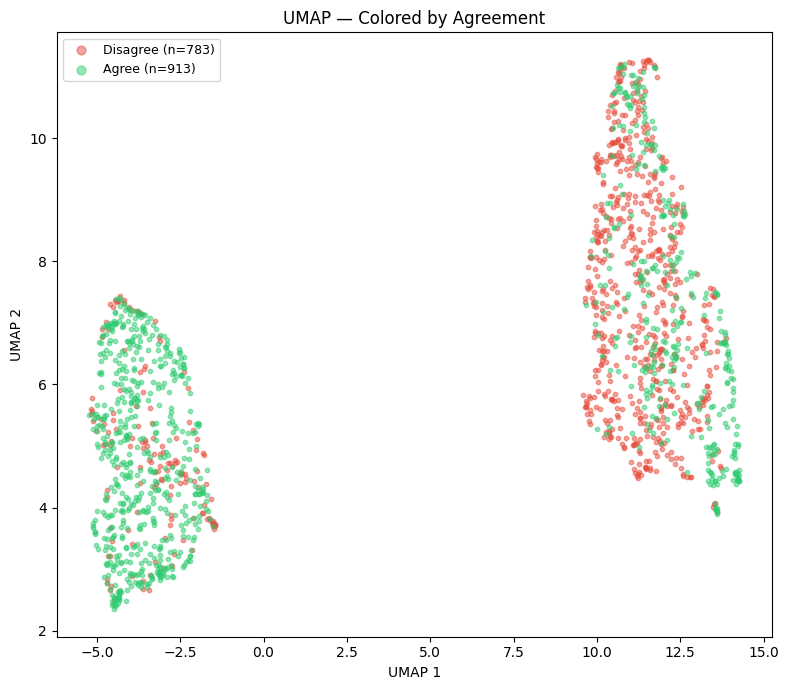

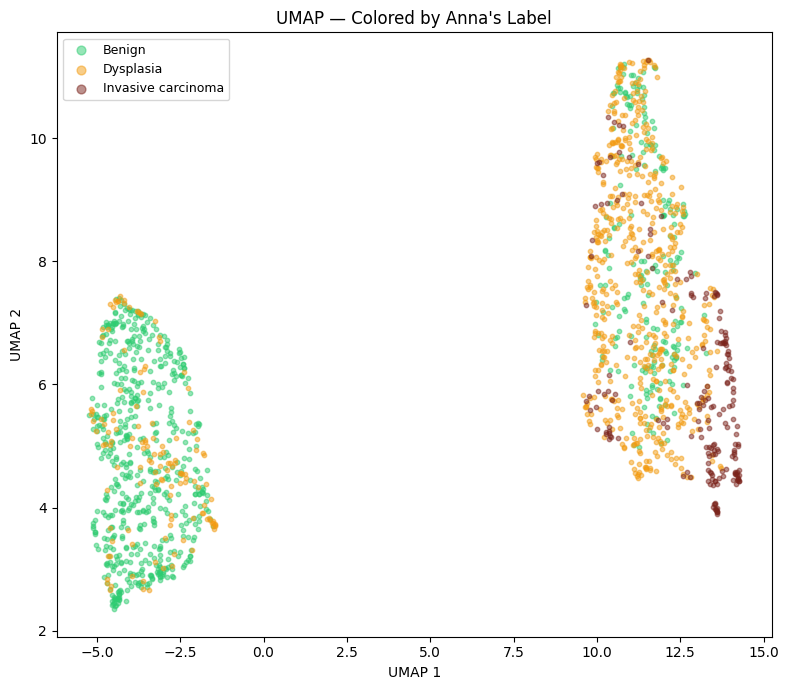

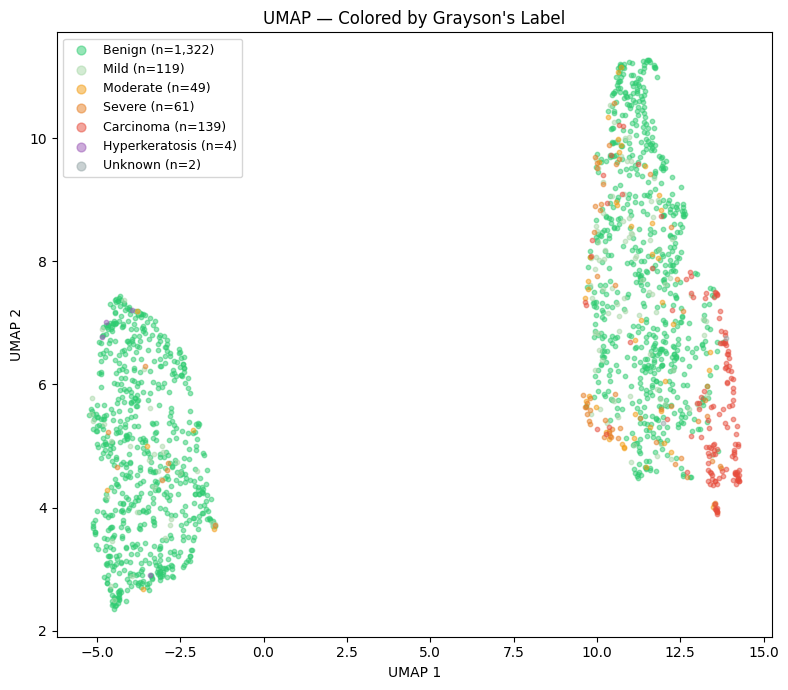

In [19]:
# --- UMAP: colored by agreement ---
fig, ax = plt.subplots(figsize=(8, 7))
agree_mask = feat_merged['agree'].values
ax.scatter(embedding[~agree_mask, 0], embedding[~agree_mask, 1],
           c='#e74c3c', alpha=0.5, s=10, label=f'Disagree (n={(~agree_mask).sum():,})')
ax.scatter(embedding[agree_mask, 0], embedding[agree_mask, 1],
           c='#2ecc71', alpha=0.5, s=10, label=f'Agree (n={agree_mask.sum():,})')
ax.set_title('UMAP — Colored by Agreement', fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

# --- UMAP: colored by Anna's label ---
fig, ax = plt.subplots(figsize=(8, 7))
anna_colors = {
    'Benign': '#2ecc71',
    'Dysplasia': '#f39c12',
    'Invasive carcinoma': '#7b241c',
}
for label, color in anna_colors.items():
    mask = feat_merged['label_anna'].values == label
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=color, label=label, alpha=0.5, s=10)
ax.set_title("UMAP — Colored by Anna's Label", fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_anna_labels.png', dpi=150, bbox_inches='tight')
plt.show()

# --- UMAP: colored by Grayson's label ---
fig, ax = plt.subplots(figsize=(8, 7))
grayson_colors = {
    'Benign': '#2ecc71',
    'Mild': '#a8d8a8',
    'Moderate': '#f39c12',
    'Severe': '#e67e22',
    'Carcinoma': '#e74c3c',
    'Hyperkeratosis': '#9b59b6',
    'Unknown': '#95a5a6',
}
for label, color in grayson_colors.items():
    mask = feat_merged['label_grayson'].values == label
    if mask.sum() == 0:
        continue
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=color, label=f'{label} (n={mask.sum():,})', alpha=0.5, s=10)
ax.set_title("UMAP — Colored by Grayson's Label", fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_grayson_labels.png', dpi=150, bbox_inches='tight')
plt.show()

## Training Strong Supervised Model (Anna's Data)


In [30]:
print('Generating Anna tile dataframe...')
anna_tile_df = anna_ds.get_tile_dataframe()
anna_tile_df = anna_tile_df.loc[anna_tile_df.label.notnull()]
print(f'Anna tiles (in ROI): {len(anna_tile_df):,}')
print(anna_tile_df.head())

Generating Anna tile dataframe...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Anna tiles (in ROI): 1,941
                   loc_x  loc_y  grid_x  grid_y roi_name roi_desc   label  \
AF136M-14900-2980  14900   2980      12       2    ROI_4    ROI_4  Benign   
AF136M-16092-2980  16092   2980      13       2    ROI_4    ROI_4  Benign   
AF136M-17284-2980  17284   2980      14       2    ROI_4    ROI_4  Benign   
AF136M-18476-2980  18476   2980      15       2    ROI_4    ROI_4  Benign   
AF136M-19668-2980  19668   2980      16       2    ROI_4    ROI_4  Benign   

                    slide  
AF136M-14900-2980  AF136M  
AF136M-16092-2980  AF136M  
AF136M-17284-2980  AF136M  
AF136M-18476-2980  AF136M  
AF136M-19668-2980  AF136M  


In [31]:
anna_tile_df

,loc_x,loc_y,grid_x,grid_y,roi_name,roi_desc,label,slide
AF136M-14900-2980,14900,2980,12,2,ROI_4,ROI_4,Benign,AF136M
AF136M-16092-2980,16092,2980,13,2,ROI_4,ROI_4,Benign,AF136M
AF136M-17284-2980,17284,2980,14,2,ROI_4,ROI_4,Benign,AF136M
AF136M-18476-2980,18476,2980,15,2,ROI_4,ROI_4,Benign,AF136M
AF136M-19668-2980,19668,2980,16,2,ROI_4,ROI_4,Benign,AF136M
...,...,...,...,...,...,...,...,...
AH063F-34953-54435,34953,54435,30,47,ROI_10,ROI_10,Dysplasia,AH063F
AH063F-36099-54435,36099,54435,31,47,ROI_10,ROI_10,Dysplasia,AH063F
AH063F-37245-54435,37245,54435,32,47,ROI_10,ROI_10,Dysplasia,AH063F
AH063F-33807-55581,33807,55581,29,48,ROI_10,ROI_10,Dysplasia,AH063F


In [33]:
# Split the dataset into training and validation.
train, val = anna_ds.split(val_fraction=0.3)


[02:18:04] INFO     No training/validation splits file provided.

           INFO     Unable to save or load validation splits.

In [ ]:
# Build model hyperparameters
#change this! The tile params may not be right adn might wanna pick a better CNN
hp = sf.ModelParams(
    tile_px=256,
    tile_um=256,
    model='xception',
    batch_size=32
)